# Ninapro DB5 — Multi-Subject Data Exploration (S1–S10)

This notebook loads all 10 subjects of the **Ninapro DB5** dataset and explores the three `.mat` files per subject:
- `S{n}_E1_A1.mat` — Basic finger movements (12 gestures)
- `S{n}_E2_A1.mat` — Isometric / isotonic hand gestures (17 gestures)
- `S{n}_E3_A1.mat` — Grasping patterns (23 gestures)

Set `SUBJECT` in the selector cell to switch which subject the visualisations target.

**Signals per file:**
| Field | Shape | Description |
|---|---|---|
| `emg` | (N, 16) | 16-channel surface EMG, 8-bit signed |
| `acc` | (N, 3) | 3-axis accelerometer |
| `glove` | (N, 22) | CyberGlove — 22 hand DoFs |
| `stimulus` | (N, 1) | Original gesture label (0 = rest) |
| `restimulus` | (N, 1) | Re-labeled gesture (recommended for classification) |
| `repetition` | (N, 1) | Repetition index |
| `rerepetition` | (N, 1) | Re-labeled repetition index |

In [19]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
BASE_DIR = Path('..') / 'public-dataset' / 'Ninapro'
mats = {}
for subj in range(1, 11):
    mats[subj] = {}
    subj_dir = BASE_DIR / f's{subj}' / f's{subj}'
    for ex in ['E1', 'E2', 'E3']:
        mats[subj][ex] = sio.loadmat(subj_dir / f'S{subj}_{ex}_A1.mat')
    total = sum(mats[subj][ex]['emg'].shape[0] for ex in ['E1', 'E2', 'E3'])
    print(f'S{subj}: {total:,} samples loaded')

S1: 568,540 samples loaded
S2: 645,244 samples loaded
S3: 575,831 samples loaded
S4: 650,748 samples loaded
S5: 651,862 samples loaded
S6: 650,177 samples loaded
S7: 654,280 samples loaded
S8: 649,994 samples loaded
S9: 649,929 samples loaded
S10: 656,710 samples loaded


In [20]:
# ── Subject selector ──────────────────────────────────────────────────────────
# Most plots show all 10 subjects. This selector is used only by the
# single-sample spot-check cells: §5 Raw EMG Signal and §6 Gesture Timeline.
SUBJECT = 10

## 1. Subject & Dataset Overview

In [21]:
print(f'{"S":<4} {"Age":>4} {"Sex":>3} {"Height(cm)":>11} {"Weight(kg)":>11} {"Hand":>5} {"Fs(Hz)":>7}')
print('-' * 46)
for s in range(1, 11):
    m      = mats[s]['E1']
    age    = m['age'][0, 0]
    gender = 'M' if m['gender'][0] == 'm' else 'F'
    height = m['height'][0, 0]
    weight = m['weight'][0, 0]
    lat    = 'R' if m['laterality'][0] == 'r' else 'L'
    fs     = int(m['frequency'][0, 0])
    print(f'S{s:<3} {age:>4.0f} {gender:>3} {height:>11.1f} {weight:>11.1f} {lat:>5} {fs:>7}')

print()
print(f'{"S":<4}', end='')
for ex in ['E1', 'E2', 'E3']:
    print(f'  {ex+" samples":>13} {"dur(min)":>9}', end='')
print()
print('-' * 85)
for s in range(1, 11):
    print(f'S{s:<3}', end='')
    for ex in ['E1', 'E2', 'E3']:
        mat = mats[s][ex]
        n  = mat['emg'].shape[0]
        fs = int(mat['frequency'][0, 0])
        print(f'  {n:>13,} {n/fs/60:>9.1f}', end='')
    print()

S     Age Sex  Height(cm)  Weight(kg)  Hand  Fs(Hz)
----------------------------------------------
S1     23   M       187.0        67.0     R     200
S2     28   M       187.0        75.0     R     200
S3     28   M       170.0        63.0     R     200
S4     22   F       156.0        52.0     R     200
S5     28   F       160.0        61.0     R     200
S6     24   M       170.0        65.0     R     200
S7     32   M       172.0        78.0     R     200
S8     31   M       170.0        74.0     R     200
S9     34   M       176.0        68.0     R     200
S10    30   M       173.0        83.0     R     200

S        E1 samples  dur(min)     E2 samples  dur(min)     E3 samples  dur(min)
-------------------------------------------------------------------------------------
S1          130,267      10.9        179,901      15.0        258,372      21.5
S2          148,367      12.4        203,945      17.0        292,932      24.4
S3          131,366      10.9        184,429      15.4

## 2. Class Balance — Rest vs. Active

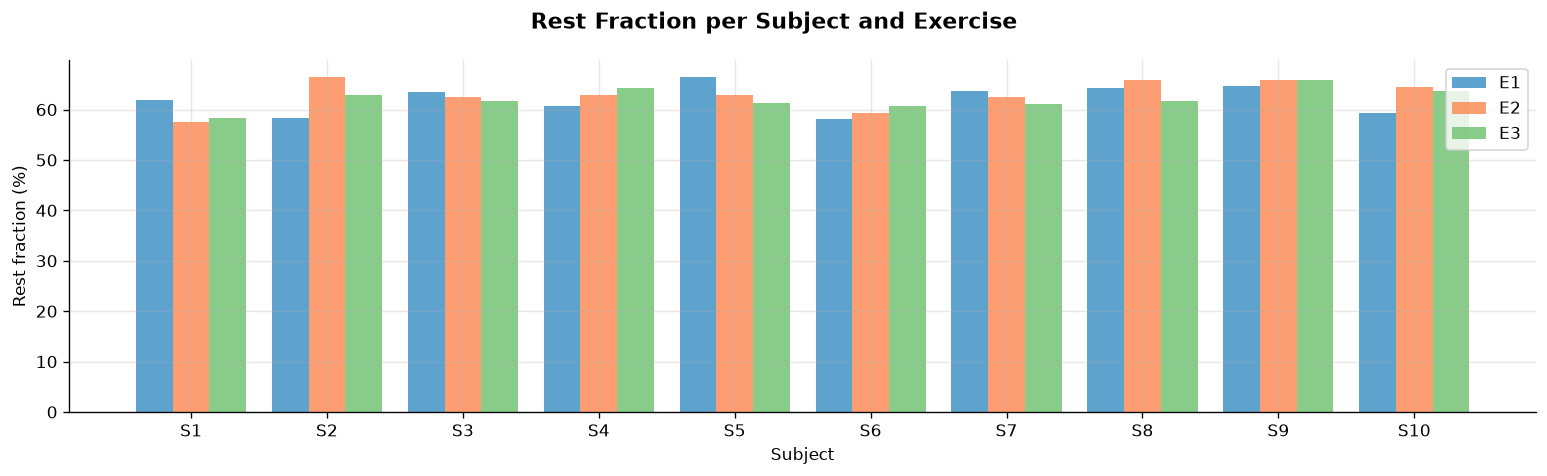

In [22]:
fig, ax = plt.subplots(figsize=(13, 4))
fig.suptitle('Rest Fraction per Subject and Exercise', fontsize=13, fontweight='bold')

x = np.arange(1, 11)
width = 0.27
colors = ['#4292c6', '#fc8d59', '#74c476']

for i, (ex, color) in enumerate(zip(['E1', 'E2', 'E3'], colors)):
    rest_pcts = [
        np.sum(mats[s][ex]['restimulus'].flatten() == 0) /
        len(mats[s][ex]['restimulus'].flatten()) * 100
        for s in range(1, 11)
    ]
    ax.bar(x + (i - 1) * width, rest_pcts, width, label=ex, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'S{s}' for s in range(1, 11)])
ax.set_xlabel('Subject')
ax.set_ylabel('Rest fraction (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. EMG Channel Activity — RMS per Electrode

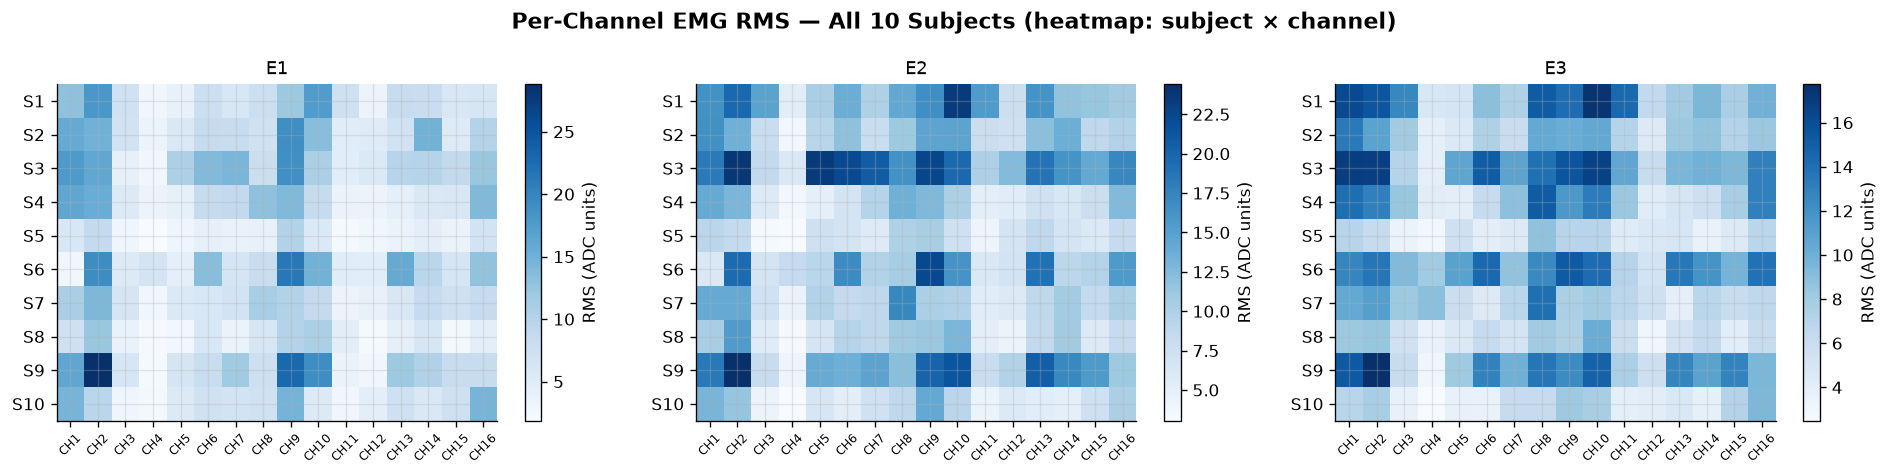


E1 top-3 channels per subject:
  S1: CH2 (18.0), CH10 (17.3), CH1 (13.0)
  S2: CH9 (19.0), CH1 (15.8), CH2 (14.8)
  S3: CH9 (18.8), CH1 (17.7), CH2 (16.1)
  S4: CH1 (16.2), CH2 (15.5), CH9 (13.9)
  S5: CH9 (10.2), CH2 (8.7), CH16 (6.9)
  S6: CH9 (21.2), CH2 (19.2), CH13 (15.7)
  S7: CH2 (14.1), CH8 (11.2), CH1 (11.0)
  S8: CH2 (12.4), CH10 (10.9), CH9 (10.2)
  S9: CH2 (28.8), CH9 (23.0), CH10 (19.0)
  S10: CH9 (14.6), CH16 (14.6), CH1 (14.5)

E2 top-3 channels per subject:
  S1: CH10 (23.5), CH2 (19.7), CH9 (16.6)
  S2: CH1 (16.5), CH10 (14.7), CH9 (14.6)
  S3: CH2 (23.8), CH5 (23.5), CH9 (22.6)
  S4: CH1 (14.1), CH8 (13.5), CH2 (12.9)
  S5: CH9 (10.4), CH8 (9.9), CH1 (9.1)
  S6: CH9 (22.4), CH2 (19.6), CH13 (19.0)
  S7: CH8 (17.2), CH1 (14.0), CH2 (14.0)
  S8: CH2 (15.4), CH10 (13.0), CH9 (11.2)
  S9: CH2 (24.4), CH10 (21.3), CH13 (20.5)
  S10: CH9 (14.2), CH1 (13.0), CH2 (11.5)

E3 top-3 channels per subject:
  S1: CH10 (17.5), CH1 (16.2), CH2 (15.5)
  S2: CH1 (13.4), CH2 (10.9), CH

In [23]:
n_ch = 16
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
fig.suptitle('Per-Channel EMG RMS — All 10 Subjects (heatmap: subject × channel)', fontsize=13, fontweight='bold')

for ax, ex in zip(axes, ['E1', 'E2', 'E3']):
    heatmap = np.zeros((10, n_ch))
    for i, s in enumerate(range(1, 11)):
        emg = mats[s][ex]['emg']
        heatmap[i] = np.sqrt(np.mean(emg ** 2, axis=0))
    im = ax.imshow(heatmap, aspect='auto', cmap='Blues')
    plt.colorbar(im, ax=ax, label='RMS (ADC units)')
    ax.set_yticks(range(10))
    ax.set_yticklabels([f'S{s}' for s in range(1, 11)])
    ax.set_xticks(range(n_ch))
    ax.set_xticklabels([f'CH{c+1}' for c in range(n_ch)], fontsize=7, rotation=45)
    ax.set_title(ex, fontsize=11)

plt.tight_layout()
plt.show()

for ex in ['E1', 'E2', 'E3']:
    print(f'\n{ex} top-3 channels per subject:')
    for s in range(1, 11):
        emg = mats[s][ex]['emg']
        ch_rms = np.sqrt(np.mean(emg ** 2, axis=0))
        top = np.argsort(ch_rms)[::-1][:3]
        print(f'  S{s}: ' + ', '.join(f'CH{t+1} ({ch_rms[t]:.1f})' for t in top))

## 4. Per-Gesture EMG Intensity

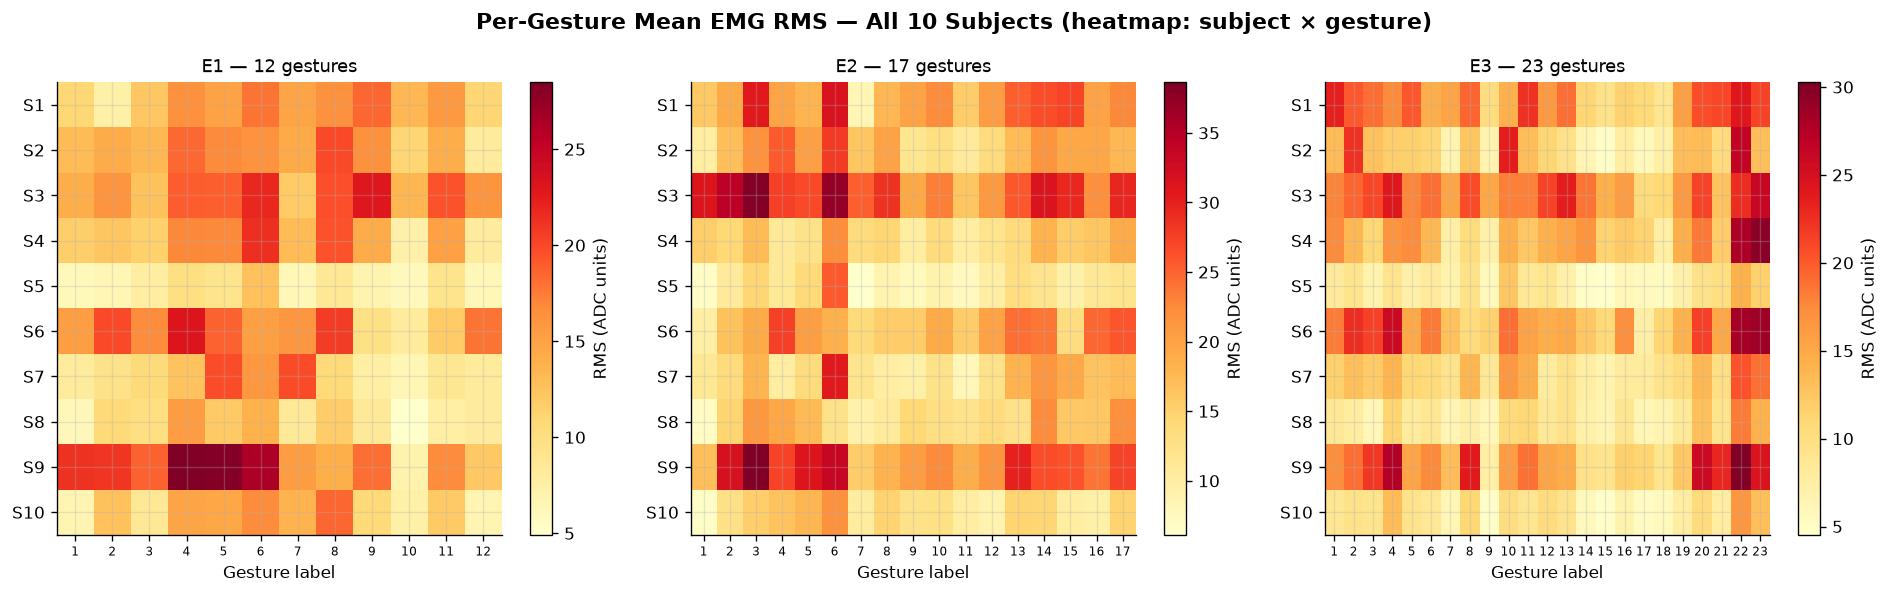

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Per-Gesture Mean EMG RMS — All 10 Subjects (heatmap: subject × gesture)', fontsize=13, fontweight='bold')

for ax, ex in zip(axes, ['E1', 'E2', 'E3']):
    active_labels = sorted([l for l in np.unique(mats[1][ex]['restimulus'].flatten()) if l != 0])
    heatmap = np.zeros((10, len(active_labels)))
    for i, s in enumerate(range(1, 11)):
        emg    = mats[s][ex]['emg']
        restim = mats[s][ex]['restimulus'].flatten()
        for j, g in enumerate(active_labels):
            seg = emg[restim == g]
            heatmap[i, j] = np.sqrt(np.mean(seg ** 2)) if len(seg) > 0 else np.nan
    im = ax.imshow(heatmap, aspect='auto', cmap='YlOrRd')
    plt.colorbar(im, ax=ax, label='RMS (ADC units)')
    ax.set_yticks(range(10))
    ax.set_yticklabels([f'S{s}' for s in range(1, 11)])
    ax.set_xticks(range(len(active_labels)))
    ax.set_xticklabels([str(g) for g in active_labels], fontsize=7)
    ax.set_xlabel('Gesture label')
    ax.set_title(f'{ex} — {len(active_labels)} gestures', fontsize=11)

plt.tight_layout()
plt.show()

## 5. Raw EMG Signal — Single Gesture Window

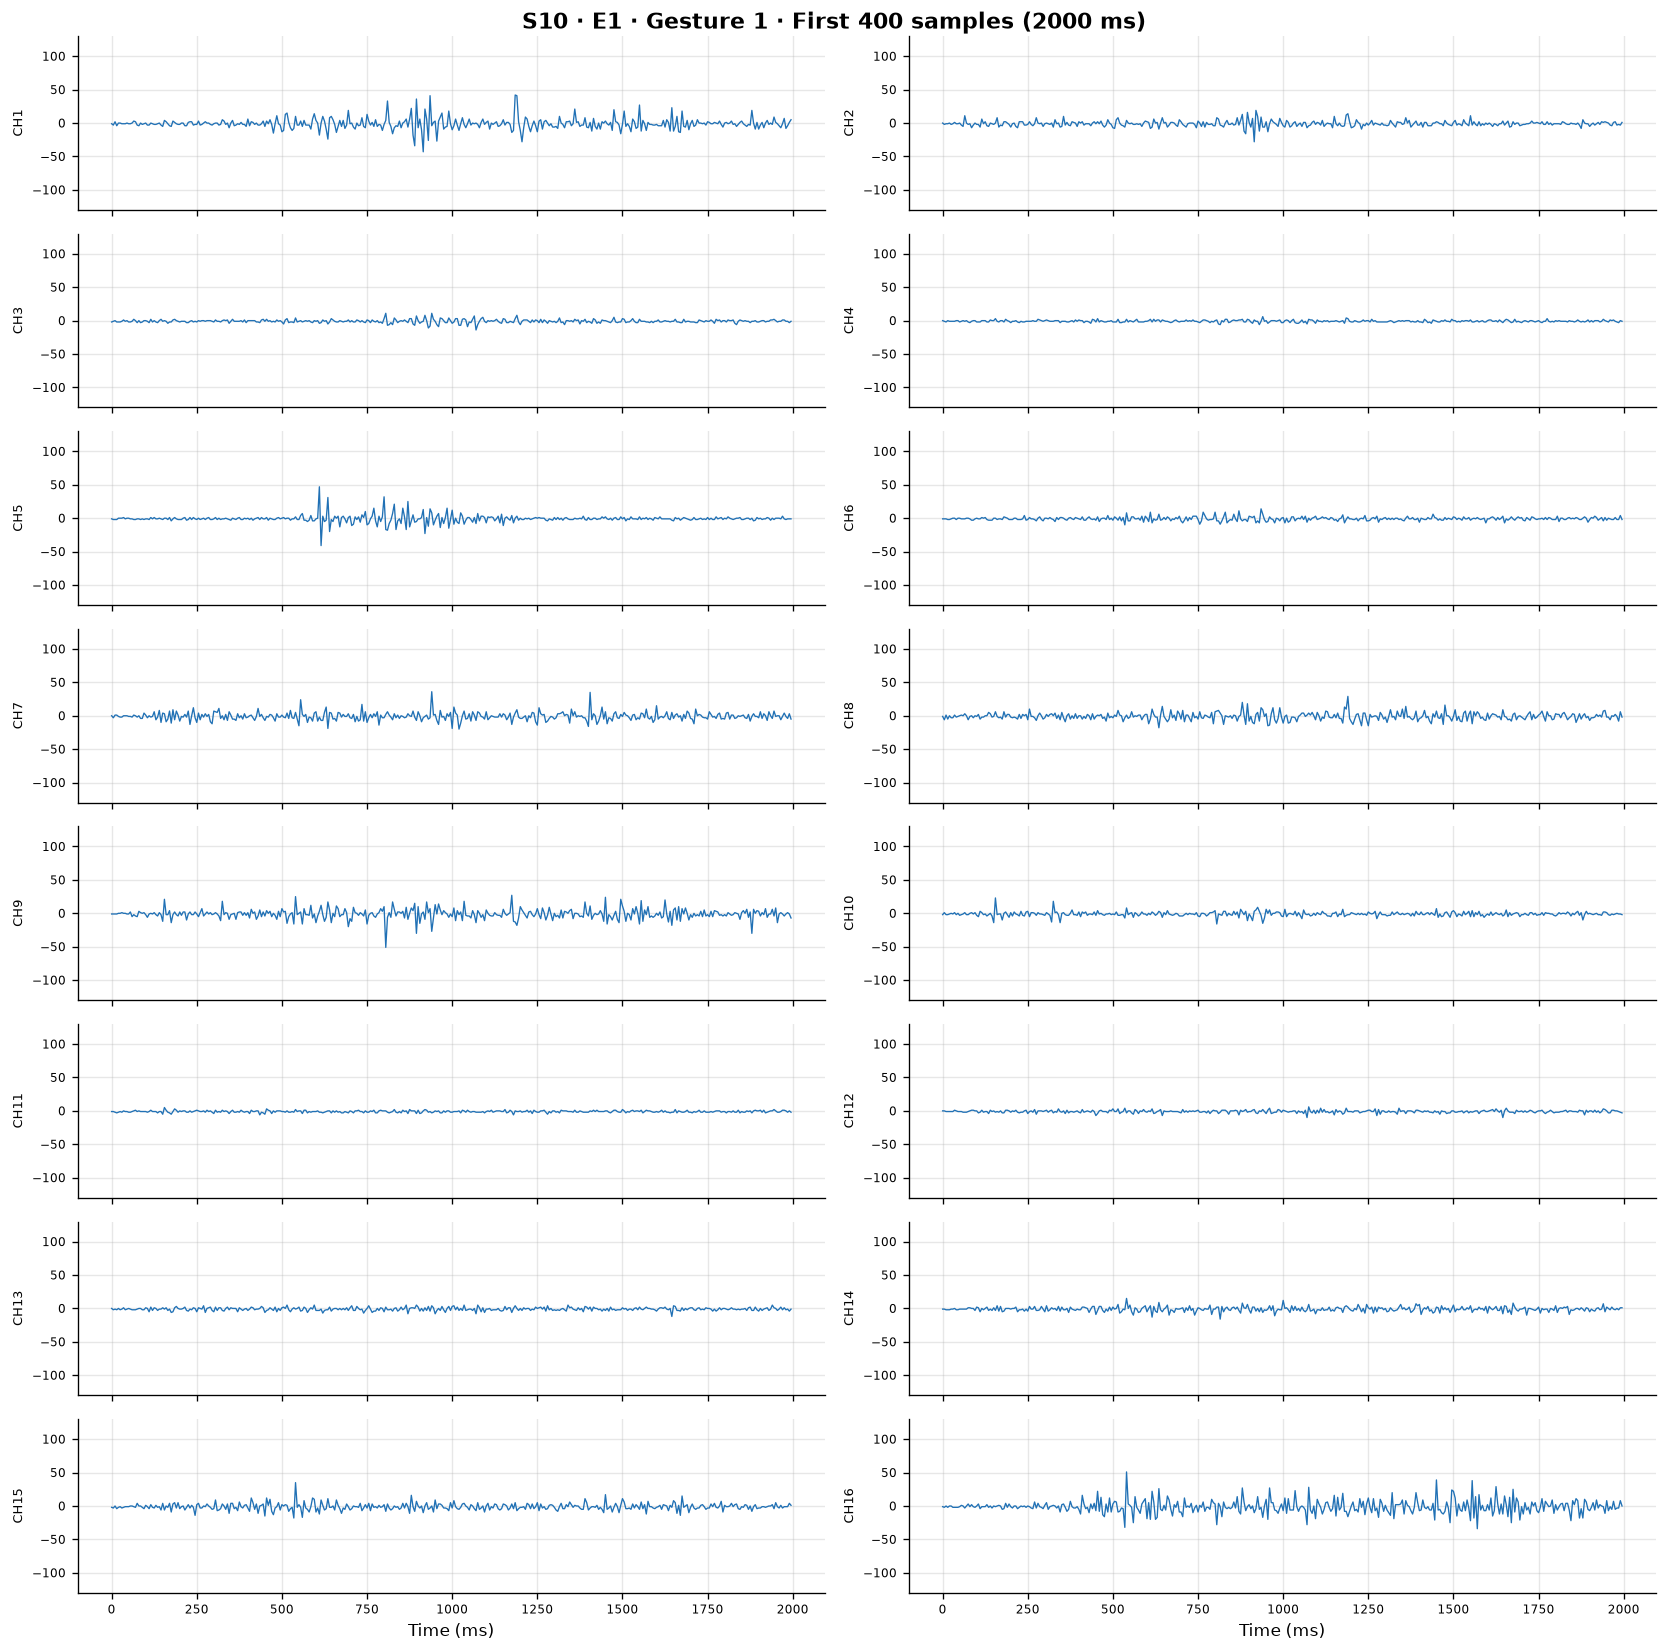

In [25]:
EXERCISE = 'E1'
GESTURE  = 1   # change to inspect other gestures
N_SAMPLES_DISPLAY = 400  # ~2 seconds at 200 Hz

emg = mats[SUBJECT][EXERCISE]['emg']
restim = mats[SUBJECT][EXERCISE]['restimulus'].flatten()
fs = int(mats[SUBJECT][EXERCISE]['frequency'][0, 0])

mask = restim == GESTURE
seg = emg[mask][:N_SAMPLES_DISPLAY]
t = np.arange(len(seg)) / fs * 1000  # ms

fig, axes = plt.subplots(8, 2, figsize=(14, 14), sharex=True)
fig.suptitle(f'S{SUBJECT} · {EXERCISE} · Gesture {GESTURE} · First {N_SAMPLES_DISPLAY} samples ({N_SAMPLES_DISPLAY/fs*1000:.0f} ms)',
             fontsize=13, fontweight='bold')

for ch in range(16):
    row, col = divmod(ch, 2)
    ax = axes[row][col]
    ax.plot(t, seg[:, ch], lw=0.8, color='#2171b5')
    ax.set_ylabel(f'CH{ch+1}', fontsize=8)
    ax.set_ylim(-130, 130)
    ax.tick_params(labelsize=7)

for ax in axes[-1]:
    ax.set_xlabel('Time (ms)')

plt.tight_layout()
plt.show()

## 6. Gesture Timeline — Stimulus Raster

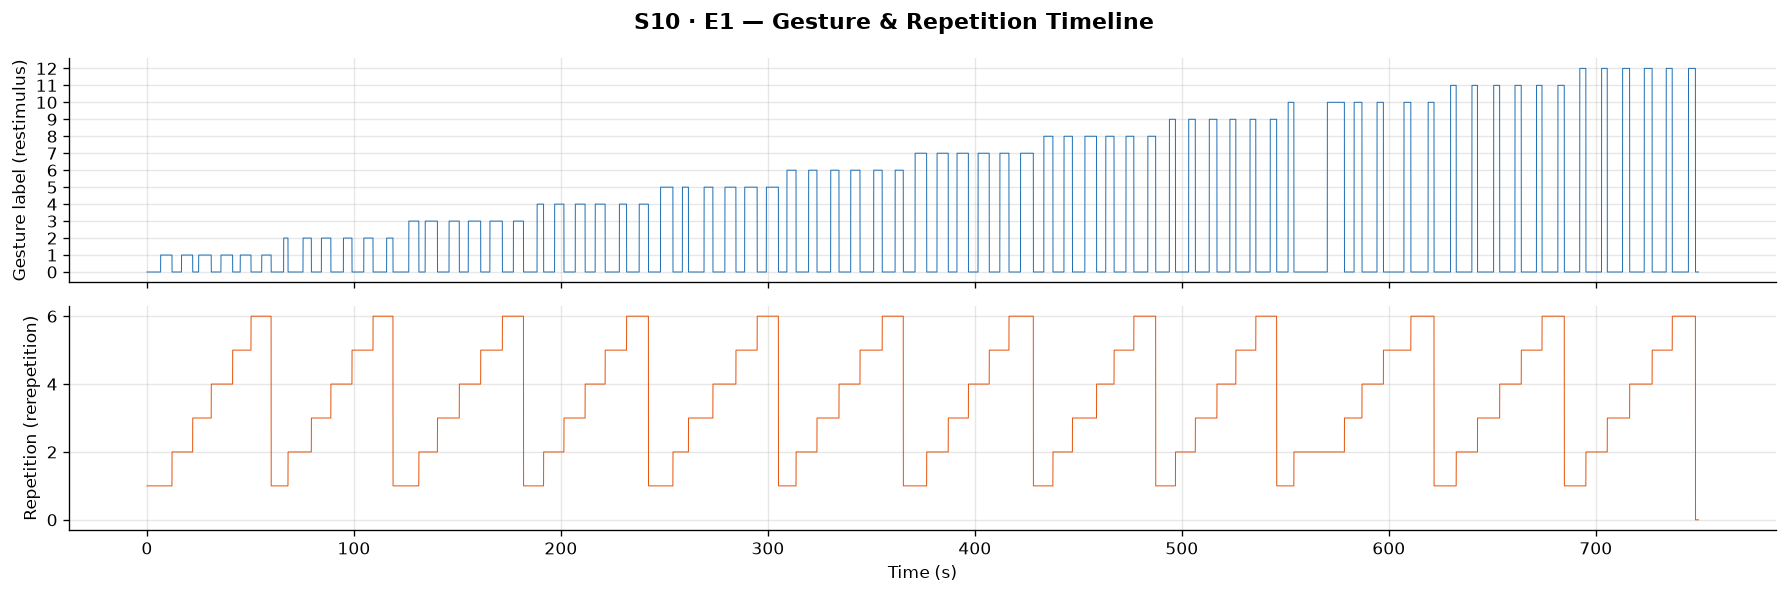

In [26]:
EXERCISE = 'E1'

restim = mats[SUBJECT][EXERCISE]['restimulus'].flatten()
rerep  = mats[SUBJECT][EXERCISE]['rerepetition'].flatten()
fs = int(mats[SUBJECT][EXERCISE]['frequency'][0, 0])
t_axis = np.arange(len(restim)) / fs

fig, axes = plt.subplots(2, 1, figsize=(15, 5), sharex=True)
fig.suptitle(f'S{SUBJECT} · {EXERCISE} — Gesture & Repetition Timeline', fontsize=13, fontweight='bold')

axes[0].plot(t_axis, restim, lw=0.6, color='#2171b5')
axes[0].set_ylabel('Gesture label (restimulus)')
axes[0].set_yticks(sorted(np.unique(restim)))

axes[1].plot(t_axis, rerep, lw=0.6, color='#e6550d')
axes[1].set_ylabel('Repetition (rerepetition)')
axes[1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

## 7. Glove Sensor — Range of Motion per DoF

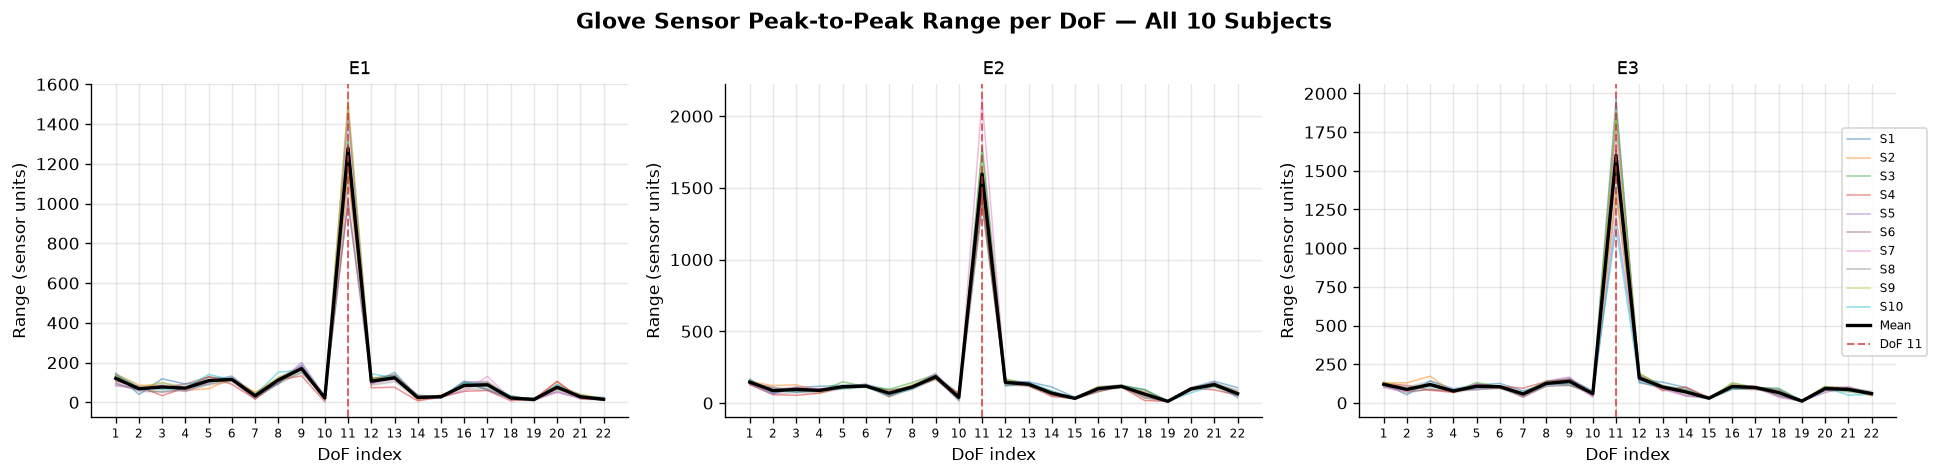

DoF 11 range vs. median of other DoFs (E1):
  S1: DoF 11 = 1213.5  |  Median others = 71.2
  S2: DoF 11 = 1157.6  |  Median others = 77.8
  S3: DoF 11 = 1312.9  |  Median others = 69.0
  S4: DoF 11 = 1298.8  |  Median others = 59.5
  S5: DoF 11 = 1002.4  |  Median others = 62.5
  S6: DoF 11 = 1016.5  |  Median others = 73.4
  S7: DoF 11 = 1468.2  |  Median others = 65.3
  S8: DoF 11 = 1482.4  |  Median others = 67.5
  S9: DoF 11 = 1524.7  |  Median others = 75.2
  S10: DoF 11 = 1298.8  |  Median others = 75.8


In [29]:
dof_idx  = np.arange(1, 23)
colors_s = plt.cm.tab10(np.linspace(0, 1, 10))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Glove Sensor Peak-to-Peak Range per DoF — All 10 Subjects', fontsize=13, fontweight='bold')

for ax, ex in zip(axes, ['E1', 'E2', 'E3']):
    all_ranges = np.zeros((10, 22))
    for i, s in enumerate(range(1, 11)):
        glove = mats[s][ex]['glove']
        all_ranges[i] = glove.max(axis=0) - glove.min(axis=0)
        ax.plot(dof_idx, all_ranges[i], color=colors_s[i], alpha=0.5, lw=0.9, label=f'S{s}')
    mean_r = all_ranges.mean(axis=0)
    std_r  = all_ranges.std(axis=0)
    ax.plot(dof_idx, mean_r, 'k-', lw=2, label='Mean')
    ax.fill_between(dof_idx, mean_r - std_r, mean_r + std_r, color='k', alpha=0.12)
    ax.axvline(11, color='#d62728', lw=1.2, linestyle='--', alpha=0.7, label='DoF 11')
    ax.set_xticks(dof_idx)
    ax.set_xticklabels([str(d) for d in dof_idx], fontsize=7)
    ax.set_xlabel('DoF index')
    ax.set_ylabel('Range (sensor units)')
    ax.set_title(ex, fontsize=11)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', fontsize=7, bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

print('DoF 11 range vs. median of other DoFs (E1):')
for s in range(1, 11):
    glove  = mats[s]['E1']['glove']
    ranges = glove.max(axis=0) - glove.min(axis=0)
    print(f'  S{s}: DoF 11 = {ranges[10]:.1f}  |  Median others = {np.median(np.delete(ranges, 10)):.1f}')

## 8. Accelerometer Statistics

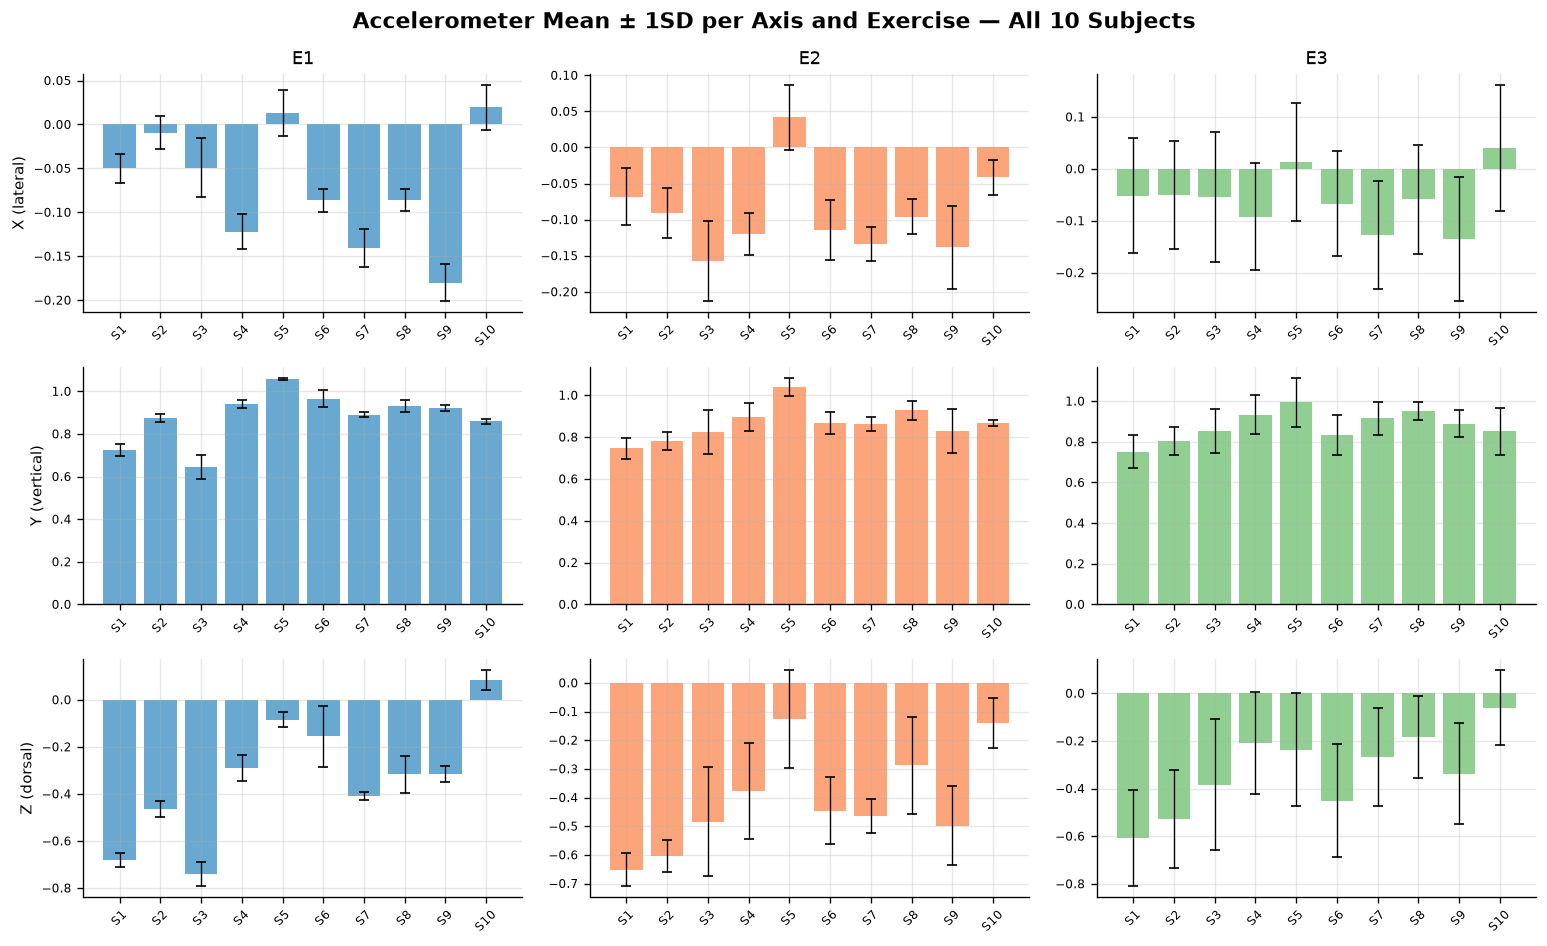

In [30]:
fig, axes = plt.subplots(3, 3, figsize=(13, 8))
fig.suptitle('Accelerometer Mean ± 1SD per Axis and Exercise — All 10 Subjects', fontsize=13, fontweight='bold')
axis_names = ['X (lateral)', 'Y (vertical)', 'Z (dorsal)']
colors = ['#4292c6', '#fc8d59', '#74c476']
x = np.arange(1, 11)

for col, (ex, color) in enumerate(zip(['E1', 'E2', 'E3'], colors)):
    for row in range(3):
        ax = axes[row][col]
        means = [mats[s][ex]['acc'][:, row].mean() for s in range(1, 11)]
        stds  = [mats[s][ex]['acc'][:, row].std()  for s in range(1, 11)]
        ax.bar(x, means, yerr=stds, color=color, alpha=0.8, capsize=3,
               error_kw={'linewidth': 0.8})
        ax.set_xticks(x)
        ax.set_xticklabels([f'S{s}' for s in range(1, 11)], fontsize=7, rotation=45)
        if col == 0:
            ax.set_ylabel(axis_names[row], fontsize=9)
        if row == 0:
            ax.set_title(ex, fontsize=11)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

## 9. Repetition Consistency — EMG RMS per Rep per Gesture (E1)

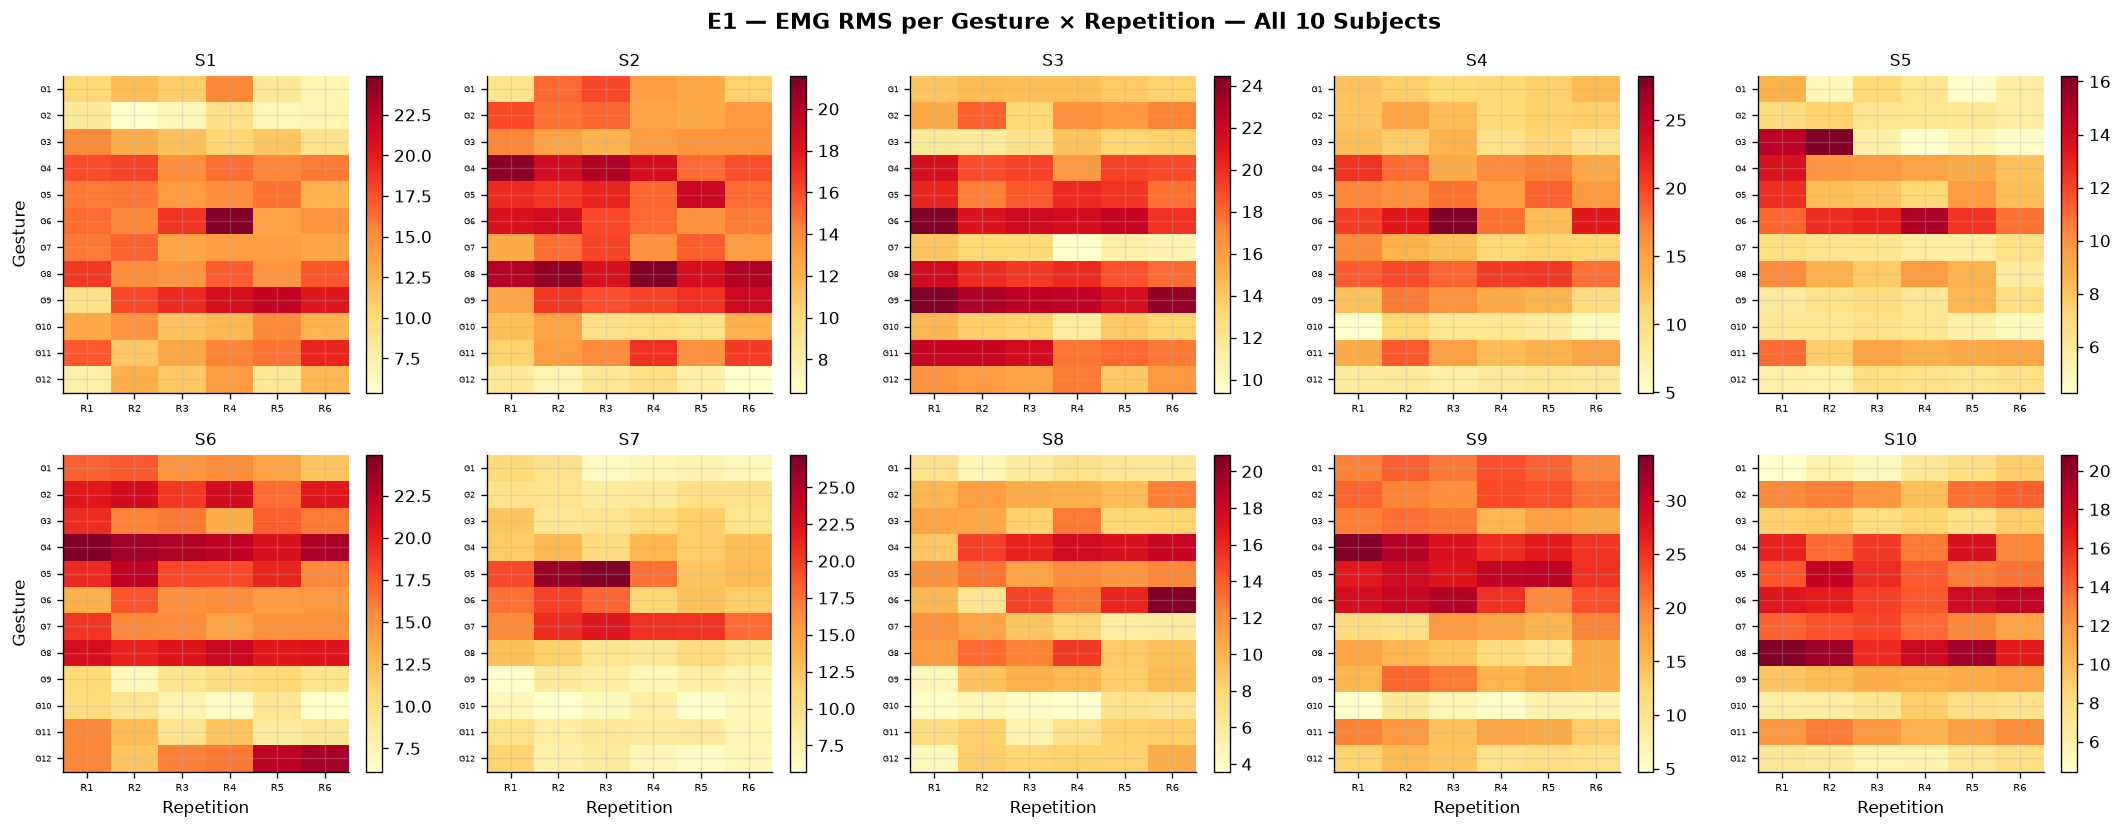

Mean gesture CV (%) across repetitions — E1:
  S1: 15.6%
  S2: 11.0%
  S3: 7.5%
  S4: 13.0%
  S5: 17.4%
  S6: 12.1%
  S7: 14.8%
  S8: 19.6%
  S9: 13.5%
  S10: 10.6%


In [31]:
EXERCISE = 'E1'
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle(f'{EXERCISE} — EMG RMS per Gesture × Repetition — All 10 Subjects', fontsize=13, fontweight='bold')

results_rep = {}
for idx, s in enumerate(range(1, 11)):
    ax     = axes[idx // 5][idx % 5]
    emg    = mats[s][EXERCISE]['emg']
    restim = mats[s][EXERCISE]['restimulus'].flatten()
    rerep  = mats[s][EXERCISE]['rerepetition'].flatten()
    active_labels = sorted([l for l in np.unique(restim) if l != 0])
    reps          = sorted([r for r in np.unique(rerep)  if r != 0])
    rms_matrix = np.zeros((len(active_labels), len(reps)))
    for i, g in enumerate(active_labels):
        for j, r in enumerate(reps):
            seg = emg[(restim == g) & (rerep == r)]
            rms_matrix[i, j] = np.sqrt(np.mean(seg ** 2)) if len(seg) > 0 else np.nan
    results_rep[s] = (rms_matrix, active_labels, reps)
    im = ax.imshow(rms_matrix, aspect='auto', cmap='YlOrRd')
    plt.colorbar(im, ax=ax)
    ax.set_title(f'S{s}', fontsize=10)
    ax.set_xticks(range(len(reps)))
    ax.set_xticklabels([f'R{r}' for r in reps], fontsize=6)
    ax.set_yticks(range(len(active_labels)))
    ax.set_yticklabels([f'G{g}' for g in active_labels], fontsize=5)
    if idx % 5 == 0:
        ax.set_ylabel('Gesture')
    if idx >= 5:
        ax.set_xlabel('Repetition')

plt.tight_layout()
plt.show()

print(f'Mean gesture CV (%) across repetitions — {EXERCISE}:')
for s in range(1, 11):
    rms_matrix, active_labels, _ = results_rep[s]
    cv = np.nanstd(rms_matrix, axis=1) / np.nanmean(rms_matrix, axis=1) * 100
    print(f'  S{s}: {np.nanmean(cv):.1f}%')

## 10. Summary Statistics

In [32]:
hdr = f'{"S":<4} {"Ex":<4} {"Samples":>10} {"Dur(m)":>7} {"Gestures":>9} {"Fs":>5} {"RMS":>7} {"Rest%":>6} {"PeakCh":>8}'
print(hdr)
print('=' * len(hdr))
for s in range(1, 11):
    for ex in ['E1', 'E2', 'E3']:
        m      = mats[s][ex]
        emg    = m['emg']
        restim = m['restimulus'].flatten()
        fs     = int(m['frequency'][0, 0])
        n      = emg.shape[0]
        n_g    = len(np.unique(restim)) - 1
        rms    = np.sqrt(np.mean(emg ** 2))
        rest_p = np.sum(restim == 0) / n * 100
        ch_rms = np.sqrt(np.mean(emg ** 2, axis=0))
        top_ch  = np.argmax(ch_rms) + 1
        top_rms = ch_rms.max()
        print(f'S{s:<3} {ex:<4} {n:>10,} {n/fs/60:>7.1f} {n_g:>9} {fs:>5} {rms:>7.2f} {rest_p:>6.1f} CH{top_ch}({top_rms:.1f})')
    if s < 10:
        print()

S    Ex      Samples  Dur(m)  Gestures    Fs     RMS  Rest%   PeakCh
S1   E1      130,267    10.9        12   200    9.51   61.9 CH2(18.0)
S1   E2      179,901    15.0        17   200   14.31   57.5 CH10(23.5)
S1   E3      258,372    21.5        23   200   11.57   58.3 CH10(17.5)

S2   E1      148,367    12.4        12   200   10.43   58.3 CH9(19.0)
S2   E2      203,945    17.0        17   200   11.17   66.4 CH1(16.5)
S2   E3      292,932    24.4        23   200    8.46   63.0 CH1(13.4)

S3   E1      131,366    10.9        12   200   11.50   63.4 CH9(18.8)
S3   E2      184,429    15.4        17   200   17.73   62.6 CH2(23.8)
S3   E3      260,036    21.7        23   200   12.26   61.6 CH1(16.9)

S4   E1      151,664    12.6        12   200    9.51   60.8 CH1(16.2)
S4   E2      206,211    17.2        17   200    9.32   62.9 CH1(14.1)
S4   E3      292,873    24.4        23   200    9.70   64.2 CH8(15.1)

S5   E1      148,526    12.4        12   200    5.13   66.5 CH9(10.2)
S5   E2      20